# Introduction

This notebook intends to produce a model that predict ice formation on sidewalk/road surface using basic weather data such as temperature, dew point temperature, wind speed, gust speed. The model trained on the Road Weather Information Stations (RWIS). 

Two models are being considered here:
- Logistics Regression
- Long Short Term Memory Model

# Download Dataset from RWIS API

In [11]:
import requests
import pandas as pd
import numpy as np
import os

In [36]:

url = "https://mesonet.agron.iastate.edu/cgi-bin/request/rwis.py"
network = "VT_RWIS" # Vermont
stations = "_ALL" # Select All Stations
format = "txt"
start = "2015-01-01T00:00" # Start Timestamp
end = "2025-01-01T00:00" # End Timestamp
tz = "America%2FChicago" # Timezone
src = "atmos"

api_url = (
    f"{url}?"
    f"network={network}&"
    f"stations={stations}&"
    f"tz={tz}&"
    f"what={format}&"
    f"src={src}&"
    f"sts={start}&"
    f"ets={end}"
)

output_filename = 'rwis_vt.txt'
print("GET: " + api_url)

try:
  response = requests.get(api_url)

  response.raise_for_status()

  # Create directory if it doesn't exist
  output_dir = '/content/dataset'
  if not os.path.exists(output_dir):
      os.makedirs(output_dir)

  # Define the output file path
  output_file = os.path.join(output_dir, output_filename)

  # Write the content to a file
  with open(output_file, 'wb') as f:
      f.write(response.content)

  print(f"File successfully downloaded to: {output_file}")

except requests.exceptions.RequestException as e:
        print(f"Error making API request: {e}")
except Exception as e:
    print(f"Error: {e}")

GET: https://mesonet.agron.iastate.edu/cgi-bin/request/rwis.py?network=VT_RWIS&stations=_ALL&tz=America%2FChicago&what=txt&src=atmos&sts=2015-01-01T00:00&ets=2025-01-01T00:00
File successfully downloaded to: /content/dataset/rwis_vt.txt


# Process Dataset

The full documentation for RWIS dataset can be found here: https://mesonet.agron.iastate.edu/request/rwis/fe.phtml

We're interested these columns below:

*   **tmpf** - temperature in F
*   **dwpf** - dew point temperature in F
* **sknt** - windspeed in knots
* **gust** - gust wind in knots
* surface conditions (**tfs0_text, tfs1_text, tfs2_text, tfs3_text**)




In [19]:
output_file = 'content/dataset/rwis_vt.txt'
df = pd.read_csv(output_file, delimiter=',')
print("\nData Preview:")
print(df.head())

/var/folders/qc/m5wrcqtn4zs_2p55xb311l7w0000gn/T/ipykernel_41561/1184354126.py:2: DtypeWarning: Columns (11,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(output_file, delimiter=',')



Data Preview:
  station    tmpf     dwpf   drct     sknt  tfs0    tfs1    tfs2    tfs3  \
0   VT008  20.318  5.73800  220.0  23.3100   NaN     NaN     NaN     NaN   
1   VT013  22.658  8.07797  220.0  29.1375   NaN     NaN     NaN  17.978   
2   VT004  14.738  4.11801  190.0   1.9425   NaN  14.918  14.918     NaN   
3   VT006  20.678  4.47797  230.0  23.3100   NaN     NaN     NaN     NaN   
4   VT002  18.338  5.73800  275.0  29.1375   NaN     NaN     NaN     NaN   

   subf      gust tfs0_text  tfs1_text tfs2_text  tfs3_text      pcpn  vsby  \
0   NaN  54.39010       NaN        NaN       NaN        NaN  0.000000   NaN   
1   NaN  50.50510       NaN        NaN       NaN        NaN       NaN   NaN   
2   NaN   9.71251       NaN        NaN       NaN        NaN  0.007874   NaN   
3   NaN  40.79250       NaN        NaN       NaN        NaN  0.015748   NaN   
4   NaN  64.10260       NaN        NaN       NaN        NaN  0.003937   NaN   

                obtime  latitude  longitude  
0  2015

## Basic

In addition to the existing columns above, we created some new columns from timestamp

*   **year** - int
*   **month** - int (1 -> 12)
* **iswinter** - binary (0, 1) 1 being winter
* **isday** - binary (0, 1) 1 being winter



In [20]:
df['obtime'] = df['obtime'].astype(str)
df['obtime'] = pd.to_datetime(df['obtime'], format='%Y-%m-%d %H:%M:%S')
df['year'] = df['obtime'].dt.year
df['month'] = df['obtime'].dt.month
df['iswinter'] = df['month'].isin([12, 1, 2, 3]).astype(int) # 1 if winter, 0 if not winter
df['isday'] = ((df['obtime'].dt.hour >= 6) & (df['obtime'].dt.hour <= 18)).astype(int) # if night or day time

In [21]:
df = df.drop(df[(df['iswinter'] == 0)].index) # drop all months besides Nov to Mar
df = df.dropna(subset=['tmpf', 'dwpf', 'gust', 'sknt', 'obtime']) # drop all rows with NaN values

## Station Unique ID

New column: **stationid**

The purpose for this id is to group the individual station to their respective winter season.

For example: **VT019-19-20** for the winter season of 2019-2020 at station **VT019**

In [22]:
# Return an ID for the winter season with the station ID

def get_winter(row):
    if row['month'] in [11, 12]:  # If month is Nov or Dec
        winter = f"{row['station']}-{str(row['year'])[2:]}-{str(row['year']+1)[2:]}"
    else:  # If month is Jan, Feb, or Mar
        winter = f"{row['station']}-{str(row['year']-1)[2:]}-{str(row['year'])[2:]}"
    return winter

df['stationid'] = df.apply(get_winter, axis=1) # Create a cluster ID for each winter season at each station

## Relative Humidity

New column: **rh** <br>
Calculated using **tmpf** and **dwpf**

In [23]:
def calc_rh(tmpf, dwpf):
    e_ta = 6.112 * np.exp((17.67 * (tmpf - 32) * 5.0/9.0) / ((tmpf - 32) * 5.0/9.0 + 243.5))
    e_td = 6.112 * np.exp((17.67 * (dwpf - 32) * 5.0/9.0) / ((dwpf - 32) * 5.0/9.0 + 243.5))

    rh = 100 * (e_td / e_ta)
    return rh

df['rh'] = calc_rh(df['tmpf'], df['dwpf']) # Calculate relative humidity

## Surface Conditions

New column: **conditions** <br>
Calculated using **tfs0_text, tfs1_text, tfs2_text, tfs3_text**

In [24]:
# Many stations have multiple ground condition sensors, so we need to find the most common value
# For example: (Wet, NaN, Wet) should be Wet
def fast_majority_vote(df, cols):
    def get_mode(row):
        # Get value counts of non-NaN values
        counts = row.value_counts()
        if len(counts) == 0:
            return np.nan
        # Check if most common value appears more than half of non-NaN values
        if counts.iloc[0] > row.count()/2:
            return counts.index[0]
        return np.nan

    return df[cols].apply(get_mode, axis=1)

df['conditions'] = fast_majority_vote(df, ['tfs0_text', 'tfs1_text', 'tfs2_text', 'tfs3_text']) # Get most common ground condition
df = df.dropna(subset=['conditions']) # Drop rows with NaN values in conditions

In [25]:
condtion_unique = df['conditions'].unique()
print(condtion_unique)

['Moist' 'Snow/Ice Watch' 'Wet' 'Snow/Ice Warning' 'Slush' 'Dry' 'Frost']


## Ice Surface Condition

New column: **isice**

Calculated using **conditions**

In [26]:
df['isice'] = df['conditions'].str.contains('Ice|Frost|Slush', case=False).astype(int) # 1 if ice or frost, 0 if not

In [27]:
ice_count = df['isice'].value_counts()
print(ice_count)

isice
0    661287
1     81446
Name: count, dtype: int64


## Sort:  Station ID and Time

For sequential input LSTM

Group 1:
```
VT02-20-21 ...... 2020-11-01 00:05:02
VT02-20-21 ...... 2020-11-01 00:35:02
```

Group 2
```
VT01-20-21 ...... 2020-11-01 00:05:02
VT01-20-21 ...... 2020-11-01 00:35:02
```





In [28]:
df = df.sort_values(['stationid', 'obtime'])

## Time Difference

New columns: **tdiff**

Calculated using **obtime**, by comparing the time difference between previous row

In the dataset, the sequenctial data were not recorded at a constant interval. For example, an interval may look like this in a station:
10min, 20min, 15 min ....

LSTM model required the interval to be constant.

In [29]:
df['tdiff'] = df['obtime'].diff().dt.total_seconds() / 60 # to minute
df['tdiff'] = df['tdiff'].fillna(0)

In [30]:
df = df.drop(df[(df['tdiff'] > 60) | (df['tdiff'] < 0)].index) # Drop rows with time difference greater than 60 minutes
df['tdiff'] = df['obtime'].diff().dt.total_seconds() / 60 # to minute
df['tdiff'] = df['tdiff'].fillna(0)

## Group by Station ID

In [31]:
df = df.groupby('stationid').filter(lambda x: len(x) >= 100)
station = df['stationid'].unique()
counts = df.groupby('stationid').size()

## Output

In [32]:
output = df[['stationid', 'tmpf', 'dwpf', 'rh', 'sknt','gust', 'tdiff', 'conditions', 'isday',  'isice']]

In [33]:
output.sample(4)

,stationid,tmpf,dwpf,rh,sknt,gust,tdiff,conditions,isday,isice
2219713,VT007-22-23,19.580000,14.540022,80.429657,1.943844,4.276458,35.0,Snow/Ice Warning,0,1
3092998,VT018-23-24,28.040022,22.819979,80.500485,5.831533,10.496760,30.0,Moist,1,0
1558619,VT029-21-22,26.419977,10.399989,50.253935,3.110151,8.552916,15.0,Dry,1,0
2201897,VT033-22-23,28.760012,24.980000,85.553826,2.138229,4.470842,15.0,Dry,0,0


Make sure the output doesn't have any NA values. Otherwise the model won't be happy.

In [34]:
print(output.isna().any().any())
columns_with_nan = output.columns[output.isna().any()].tolist()
print(columns_with_nan)

False
[]


In [36]:
output_dir = 'content/clean'
if not os.path.exists(output_dir):
  os.makedirs(output_dir)
output.to_csv(output_dir+'/vt.csv')

# LSTM Model

In [99]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam

In [100]:
data = pd.read_csv('content/clean/vt.csv', sep=',')

In [101]:
features = ['tmpf', 'rh', 'sknt', 'gust', 'tdiff', 'isday']
target = 'isice'
X = data[features].values
y = data[target].values

## Normalization

In [102]:
# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Data Transformation

In [103]:
def get_event_windows(X, y, sequence_length, window_size, include_non_events=True):
    """
    Extract windows around ice events (where y=1) and optionally include some non-event periods

    Parameters:
    -----------
    X : array-like
        Input features
    y : array-like
        Target values
    sequence_length : int
        Length of each sequence
    window_size : int
        Number of time steps before and after an event to include
    include_non_events : bool
        Whether to include some non-event periods
    """
    event_indices = np.where(y == 1)[0]
    X_windows = []
    y_windows = []

    # Get sequences around events
    for idx in event_indices:
        # Define window boundaries
        start = max(0, idx - window_size)
        end = min(len(X), idx + window_size)

        # Extract sequences within this window
        for i in range(start, end - sequence_length):
            X_windows.append(X[i:(i + sequence_length)])
            y_windows.append(y[i + sequence_length])

    if include_non_events:
        # Get some non-event sequences (randomly sampled)
        non_event_indices = np.where(y == 0)[0]
        # Sample same number of non-events as events
        sample_size = min(len(event_indices) * window_size, len(non_event_indices))
        sampled_indices = np.random.choice(non_event_indices, size=sample_size, replace=False)

        for idx in sampled_indices:
            if idx + sequence_length < len(X):
                X_windows.append(X[idx:(idx + sequence_length)])
                y_windows.append(y[idx + sequence_length])

    return np.array(X_windows), np.array(y_windows)

In [104]:
# Parameters
sequence_length = 10
window_size = 24

X_sequences = []
y_sequences = []

# Group by station and get sequences around events
for station in df['stationid'].unique():
    station_mask = df['stationid'] == station
    station_X = X_scaled[station_mask]
    station_y = y[station_mask]

    # Get sequences around events
    X_event, y_event = get_event_windows(station_X, station_y,
                                        sequence_length,
                                        window_size,
                                        include_non_events=True)

    if len(X_event) > 0:
        X_sequences.extend(X_event)
        y_sequences.extend(y_event)

# Convert to numpy arrays
X_sequences = np.array(X_sequences, dtype='float32')
y_sequences = np.array(y_sequences, dtype='float32')

# Print information about the dataset
print("Final shapes:")
print("X_sequences shape:", X_sequences.shape)
print("y_sequences shape:", y_sequences.shape)
print("\nClass distribution:")
print(np.bincount(y_sequences.astype(int)))
print("\nPercentage of ice events:", np.mean(y_sequences) * 100, "%")

# Optional: Shuffle the data
indices = np.arange(len(X_sequences))
np.random.shuffle(indices)
X_sequences = X_sequences[indices]
y_sequences = y_sequences[indices]

Final shapes:
X_sequences shape: (3678726, 10, 6)
y_sequences shape: (3678726,)

Class distribution:
[1644372 2034354]

Percentage of ice events: 55.300503969192505 %


## Training/Testing Split

In [105]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_sequences, y_sequences, test_size=0.2, random_state=42
)

## Build Model

In [106]:
# Build LSTM Model

model = Sequential([
    LSTM(128, input_shape=(sequence_length, len(features)), return_sequences=True),  # Changed to True
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.001),  # Specify learning rate here
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

/opt/miniconda3/envs/engs90/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_19 (LSTM)                  │ (None, 10, 128)        │        69,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_20 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,153 (473.25 KB)

 Trainable params: 121,153 (473.25 KB)

 Non-trainable params: 0 (0.00 B)

## Train

In [107]:
history = model.fit(X_train, y_train,
                   epochs=10,
                   batch_size=32,
                   validation_split=0.2,
                   verbose=1)

Epoch 1/10
73575/73575 ━━━━━━━━━━━━━━━━━━━━ 454s 6ms/step - accuracy: 0.7627 - loss: 0.5008 - val_accuracy: 0.8198 - val_loss: 0.4009
Epoch 2/10
73575/73575 ━━━━━━━━━━━━━━━━━━━━ 457s 6ms/step - accuracy: 0.8296 - loss: 0.3821 - val_accuracy: 0.8726 - val_loss: 0.3025
Epoch 3/10
73575/73575 ━━━━━━━━━━━━━━━━━━━━ 458s 6ms/step - accuracy: 0.8701 - loss: 0.3071 - val_accuracy: 0.8976 - val_loss: 0.2537
Epoch 4/10
73575/73575 ━━━━━━━━━━━━━━━━━━━━ 454s 6ms/step - accuracy: 0.8917 - loss: 0.2651 - val_accuracy: 0.9119 - val_loss: 0.2246
Epoch 5/10
73575/73575 ━━━━━━━━━━━━━━━━━━━━ 487s 7ms/step - accuracy: 0.9034 - loss: 0.2407 - val_accuracy: 0.9214 - val_loss: 0.2043
Epoch 6/10
73575/73575 ━━━━━━━━━━━━━━━━━━━━ 472s 6ms/step - accuracy: 0.9121 - loss: 0.2232 - val_accuracy: 0.9285 - val_loss: 0.1900
Epoch 7/10
73575/73575 ━━━━━━━━━━━━━━━━━━━━ 480s 7ms/step - accuracy: 0.9179 - loss: 0.2104 - val_accuracy: 0.9353 - val_loss: 0.1745
Epoch 8/10
73575/73575 ━━━━━━━━━━━━━━━━━━━━ 475s 6ms/step - ac

## Result

### Test

In [108]:
# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f'\nTest accuracy: {test_accuracy:.3f}')



22993/22993 ━━━━━━━━━━━━━━━━━━━━ 39s 2ms/step - accuracy: 0.9423 - loss: 0.1605

Test accuracy: 0.942


### Confusion Matrix

22993/22993 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step


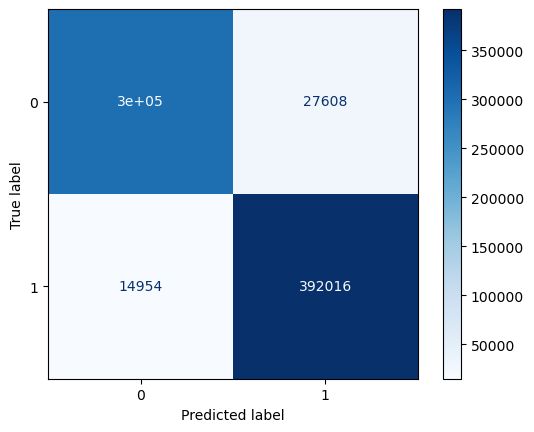

In [109]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

# Make sure both y_test and y_pred are in the same format
y_test = y_test.astype(int)
y_pred = (y_pred > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.show()

## Save Model

In [110]:
import joblib

# Save Model
model.save('content/result/model_lstm.keras')
print("Model saved to content/result/model_lstm.keras")

# Save Scaler file
joblib.dump(scaler, 'content/scaler_lstm.pkl')
print("Scaler saved to content/scaler_lstm.pkl")


Model saved to content/result/model_lstm.keras
Scaler saved to content/scaler_lstm.pkl


# How to use the existing data to predict ice formation

In [ ]:
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import load_model

import numpy as np
import joblib

model = load_model('content/result/model_lstm.keras')

scaler = joblib.load('content/result/scaler_lstm.pkl')

# Example data
data = [[32.2, 91, 0, 2, 0, 1],
        [32.2, 91, 0, 2, 10, 1],
        [32.2, 91, 0, 2, 20, 1],
        [32.2, 91, 1, 2, 30, 1],
        [32.2, 91, 0, 2, 10, 1],
        [32.2, 91, 2, 2, 31, 1],
        [32.2, 91, 2, 2, 20, 1],
        [32.2, 91, 3, 2, 15, 1],
        [32.2, 91, 4, 2, 15, 1],
        [32.2, 91, 0, 2, 20, 1]]

features = ['tmpf', 'rh', 'sknt', 'gust', 'tdiff', 'isday']

X = np.array(data, dtype='float32')
X_scaled = scaler.transform(X)

sequence_length = 10

res = model.predict(X_scaled.reshape(1, sequence_length, len(features)))
print(res)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
[[0.00931355]]


# Logistic Regression

In [72]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

In [73]:
data = pd.read_csv('content/clean/vt.csv', sep=',')

features = ['tmpf', 'rh', 'sknt', 'gust', 'tdiff', 'isday']
target = 'isice'

X = data[features].values
y = data[target].values

## Train/Test Split

In [74]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Normalization

In [75]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Resample

**isice** only showed about 3% of the dataset. We want to resample the dataset so that it only showed 2%

In [76]:
smote = SMOTE(random_state=42)
# Apply SMOTE to training data
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)


## Model

In [77]:
model = LogisticRegression(random_state=42)

## Train

In [78]:
model.fit(X_train_resampled, y_train_resampled)

LogisticRegression(random_state=42)

## Results

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.73      0.83    131385
           1       0.27      0.82      0.41     16092

    accuracy                           0.74    147477
   macro avg       0.62      0.77      0.62    147477
weighted avg       0.89      0.74      0.78    147477



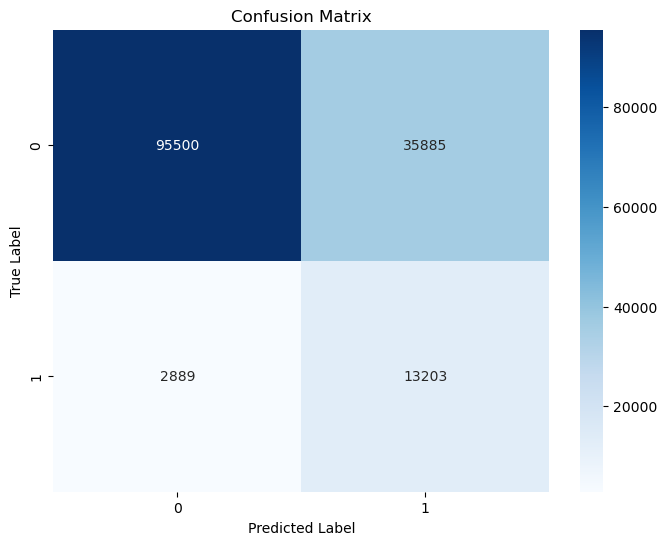

In [79]:
# Make predictions
y_pred = model.predict(X_test_scaled)
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Create confusion matrix visualization
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

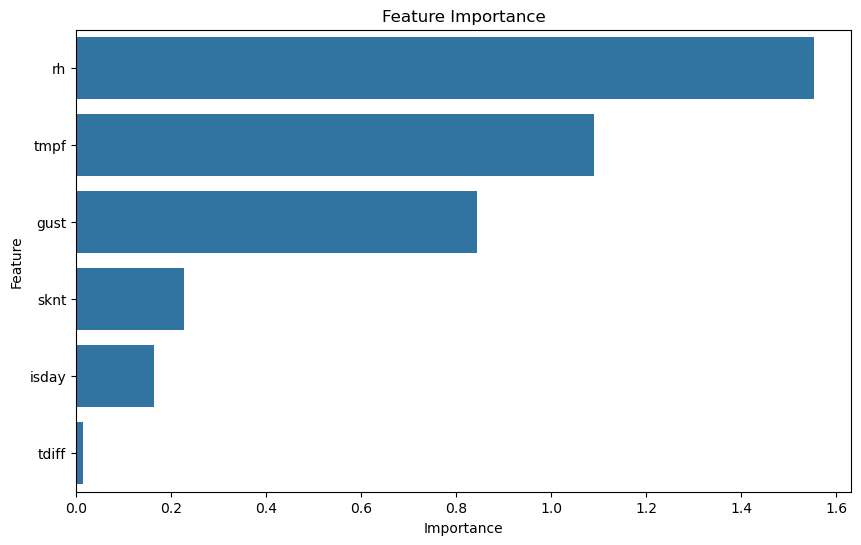

In [80]:
# Feature importance
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': abs(model.coef_[0])
})
feature_importance = feature_importance.sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Feature Importance')
plt.show()

In [81]:
# Print model coefficients
print("\nModel Coefficients:")
for feature, coef in zip(features, model.coef_[0]):
    print(f"{feature}: {coef:.4f}")


Model Coefficients:
tmpf: -1.0906
rh: 1.5531
sknt: -0.2282
gust: 0.8429
tdiff: -0.0146
isday: -0.1643
